# Laboratorio Práctico 4 · Análisis y preparación de series temporales

**Curso:** Análisis de Datos  
**Programa:** Magíster en Data Science · Universidad del Desarrollo  
**Código:** MDSC3S112-1  

**Estudiante:** Luciano Hernández

**Fecha:** 2026-09-11

---

### Objetivo

Pasar desde un conjunto de datos que contiene una fecha a una serie temporal correctamente organizada, diagnosticada y preparada para un posterior proceso de modelamiento.

> **Importante:** En este laboratorio no se requiere construir modelos ARIMA ni realizar forecasting.


## 1. Contexto del problema

En este laboratorio se analizarán datos mensuales de una organización.

El objetivo es comprender cómo evoluciona la variable `ventas_clp` a través del tiempo y determinar si los datos están correctamente preparados para un posterior análisis de series temporales.

### Preguntas orientadoras

- ¿Cuál es la variable principal que se desea analizar?
- ¿Cuál es la dimensión temporal?
- ¿Por qué puede ser relevante estudiar las ventas a través del tiempo?
- ¿Qué decisiones empresariales podrían beneficiarse de este análisis?

### Interpretación

Escriba aquí una breve descripción del problema analítico.


El análisis de la serie temporal busca evaluar el comportamiento histórico y la preparación técnica de los datos de ventas para fundamentar la toma de decisiones estratégicas de la organización.

- **Variable principal**: La métrica central de estudio es `ventas_clp`, que representa el volumen total de ventas expresado en pesos chilenos
- **Dimensión temporal**: Está definida por la columna `fecha`, estructurada con una frecuencia de registro mensual
- **Relevancia del análisis temporal**: Evaluar las ventas a lo largo del tiempo permite identificar la tendencia general del negocio (crecimiento o decrecimiento), detectar patrones de estacionalidad (comportamientos recurrentes en ciertos meses del año) y medir la volatilidad de los ingresos frente a dinámicas de mercado o promociones comerciales
- **Decisiones empresariales beneficiadas**:
    - **Planificación financiera**: Elaboración de presupuestos precisos, gestión eficiente del flujo de caja y estimación de ingresos futuros
    - **Gestión operativa**: Ajustes de capacidad y prevención de quiebres de stock o excesos de inventario durante periodos de alto volumen de ventas
    - **Estrategia comercial**: Evaluación del retorno sobre la inversión publicitaria (`inversion_marketing_clp`), análisis del impacto de estrategias de descuento (`promocion`) y ajuste del `precio_promedio` según la respuesta histórica de la demanda

**Interpretación del Problema Analítico**

El problema analítico radica en la transformación y saneamiento de un conjunto de datos transaccionales para estructurar una serie de tiempo formal, continua e inequívoca. Esto exige evaluar la calidad de los datos, garantizando que no existan interrupciones cronológicas, fechas duplicadas o valores faltantes en la variable objetivo (`ventas_clp`) e indicadores complementarios. La correcta conversión de la columna `fecha` a un índice temporal funcional es el requisito previo para asegurar que los datos cumplan con las supuestos de regularidad necesarios antes de abordar cualquier análisis de autocorrelación o modelado avanzado.

## 2. Carga del dataset

Cargue el dataset y realice una primera inspección de sus características.

Revise:

- dimensiones;
- primeras observaciones;
- nombres de variables;
- tipos de datos;
- valores faltantes;
- estadísticas descriptivas.


In [1]:
# Importación de bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller


# Carga del dataset
df = pd.read_csv("ventas_mensuales.csv")

# Complete aquí la exploración inicial

rows, cols = df.shape
colNames = list(df.columns)
print("Cantidad de registros:", rows)
print("Cantidad de variables:", cols)
colNames = list(df.columns)
dataTypes = {
    "object": "categóricas",
    "int64": "numéricas",
    "float64": "numéricas"
}
colTypes = { c: "temporales" if c == "fecha" else dataTypes[str(df[c].dtype)] for c in colNames }
lstTypes = { t: [ c for c in colNames if colTypes[c] == t ] for t in colTypes.values() }
for t, lc in lstTypes.items():
    print(f"Variables {t}:", ", ".join(lc))

Cantidad de registros: 73
Cantidad de variables: 6
Variables temporales: fecha
Variables numéricas: ventas_clp, clientes_activos, inversion_marketing_clp, precio_promedio, promocion


### Preguntas orientadoras

- ¿Cuántas observaciones existen?
- ¿Qué variables contiene el dataset?
- ¿La variable temporal está almacenada con el tipo de dato adecuado?
- ¿Existen valores faltantes?

### Interpretación

Describa brevemente la estructura inicial de los datos e identifique posibles problemas.


El dataset cuenta con una estructura inicial de 73 observaciones y 6 variables.

- **Observaciones**: Existen 73 registros (observaciones) en total
- **Variables**: El dataset contiene 6 variables, éstas son: `fecha`, `ventas_clp`, `clientes_activos`, `inversion_marketing_clp`, `precio_promedio` y `promocion`
- **Tipo de dato temporal**: Aunque la variable fecha se identifica lógicamente como temporal, el código utiliza una condición manual (`if c == "fecha"`) para etiquetarla en el output sin evaluar su tipo real en Pandas, al cargar el archivo con `pd.read_csv()` sin utilizar el parámetro de análisis de fechas, está almacenada inicialmente como texto (cadena de caracteres) y no con el tipo de dato `datetime` adecuado
- **Valores faltantes**: El output generado en esta sección no incluye información sobre datos nulos, el código no imprimió comprobaciones como `df.isnull().sum()`, por lo que es imposible determinar si existen valores faltantes basándose únicamente en esta salida

**Interpretación y posibles problemas**

Los datos presentan una estructura tabular que aísla una dimensión temporal frente a cinco métricas transaccionales y de marketing numéricas. El principal problema de esta inspección inicial es que resulta incompleta. El análisis de salida omite reportar la presencia de datos faltantes y no genera estadísticas descriptivas básicas, pasos fundamentales para diagnosticar la salud de la serie temporal. Además, la falsa confirmación del tipo de dato de la variable fecha mediante un condicional de texto oculta la necesidad técnica de castear dicha columna a un formato de tiempo real para poder utilizarla funcionalmente como índice.

## 3. Identificación de la variable temporal

Identifique la variable que representa el tiempo y conviértala al tipo de dato apropiado.

Determine:

- fecha mínima;
- fecha máxima;
- tipo de dato;
- cantidad de observaciones;
- existencia de fechas duplicadas.


In [2]:
# Conversión de la variable temporal

df1 = df.assign(
    fecha = pd.to_datetime(df["fecha"])
)

# Complete el análisis

minDate = df1["fecha"].min()
maxDate = df1["fecha"].max()
dateType = df1["fecha"].dtype
datesQuantity = len(df1["fecha"].unique())
duplicatedDates = df1["fecha"].duplicated()

print("Fecha Mínima:", minDate)
print("Fecha Máxima:", maxDate)
print("Tipo de Dato:", dateType)
print("Cantidad de Observaciones Únicas:", datesQuantity)
print("Fechas Duplicadas:")
display(df1[duplicatedDates])

Fecha Mínima: 2020-01-01 00:00:00
Fecha Máxima: 2025-12-01 00:00:00
Tipo de Dato: datetime64[ns]
Cantidad de Observaciones Únicas: 72
Fechas Duplicadas:


,fecha,ventas_clp,clientes_activos,inversion_marketing_clp,precio_promedio,promocion
52,2022-12-01,70822132.0,2146,2181424.0,31825,1


### Preguntas orientadoras

- ¿Cuál es la variable temporal?
- ¿Está correctamente representada?
- ¿Cada fecha representa una única observación?
- ¿Existen fechas duplicadas?
- ¿Qué período temporal cubren los datos?

### Interpretación

Justifique por qué la variable seleccionada puede utilizarse como dimensión temporal.


- **Variable temporal**: La variable que representa el tiempo en el conjunto de datos es `fecha`
- **Representación**: Inicialmente no estaba almacenada con el tipo de dato adecuado, pero tras la conversión se ha representado correctamente como `datetime64[ns]`
- **Unicidad y duplicados**: No todas las fechas representan una única observación, ya que existe un registro duplicado para la fecha `2022-12-01`, el dataset cuenta con 72 observaciones temporales únicas y 1 duplicada
- **Período temporal**: Los datos cubren el período comprendido desde el `2020-01-01` hasta el `2025-12-01`

**Interpretación**

La variable `fecha` es la candidata idónea para estructurar la dimensión temporal porque marca un punto específico en el tiempo para la agregación de las métricas de negocio. Al convertirla a un formato de tiempo estándar (`datetime64[ns]`), se facilita su posterior uso como índice para ordenar cronológicamente el dataset. Esto permitirá evaluar la distancia entre observaciones, confirmar si la periodicidad es realmente mensual (como indica el problema de negocio) y aplicar técnicas de análisis de series temporales. No obstante, la presencia de una fecha duplicada indica un problema de calidad de datos que deberá corregirse (por ejemplo, sumando o promediando el registro doble, o eliminándolo si es un error de digitación) antes de poder definir la columna de manera funcional como un índice temporal estricto.

## 4. Revisión de frecuencia y orden temporal

Ordene las observaciones cronológicamente y establezca la variable temporal como índice.

Analice la distancia entre observaciones consecutivas y determine la frecuencia efectiva de los datos.


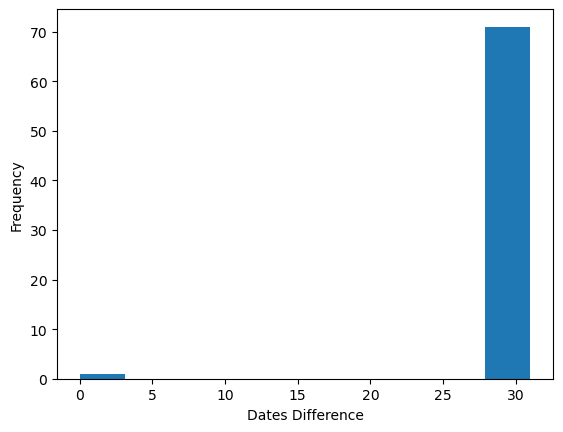

In [3]:
# Orden cronológico

df2 = df1.sort_values("fecha").copy()

df2["dates_diff"] = df2["fecha"].diff().dt.days

# Establecer índice temporal

df3 = df2.set_index("fecha")

# Complete el análisis de frecuencia

df3["dates_diff"].plot.hist()
plt.xlabel("Dates Difference")
plt.show()

### Preguntas orientadoras

- ¿Las observaciones están ordenadas cronológicamente?
- ¿Cuál es la frecuencia de observación?
- ¿La frecuencia es regular?
- ¿Existen períodos sin observaciones?
- ¿La frecuencia observada coincide con la esperada?

### Interpretación

Determine la frecuencia temporal de la serie y explique si existen problemas de regularidad.


- **Orden cronológico**: La aplicación del método `sort_values("fecha")` en el código garantiza que las observaciones queden ordenadas secuencialmente desde la fecha mínima (`2020-01-01`) hasta la máxima (`2025-12-01`), un paso técnico indispensable antes de calcular la distancia entre registros
- **Frecuencia de observación y regularidad**: La diferencia en días entre observaciones consecutivas (`dates_diff`) debería agruparse en valores de 28, 29, 30 y 31 días, lo que confirma una frecuencia efectiva mensual, sin embargo, esta frecuencia no es estrictamente regular, la existencia de una fecha duplicada (`2022-12-01`) identificada en el paso anterior introduce una distancia de 0 días, rompiendo la continuidad temporal
- **Períodos sin observaciones**: El rango temporal evaluado abarca exactamente 72 meses (6 años), dado que el análisis previo confirmó la existencia de 72 observaciones únicas, la serie se encuentra completa y no presenta períodos o huecos sin información, si faltara algún mes, el histograma evidenciaría barras atípicas con valores cercanos o superiores a los 60 días
- **Coincidencia con la frecuencia esperada**: La temporalidad observada coincide con la frecuencia mensual esperada de las métricas de negocio, no obstante, a nivel técnico, el índice temporal aún requiere limpieza (resolución del duplicado que genera el salto de 0 días) para que los algoritmos de series de tiempo puedan procesar la regularidad mensual sin errores matemáticos

## 5. Calidad y consistencia de la serie

Realice un diagnóstico de calidad específico para datos temporales.

Revise:

- valores faltantes;
- fechas duplicadas;
- orden temporal;
- continuidad;
- valores potencialmente problemáticos en la variable objetivo.

Si detecta un problema, documente la decisión tomada para abordarlo.


,ventas_clp,clientes_activos,inversion_marketing_clp,precio_promedio,promocion,dates_diff
fecha,,,,,,
2020-01-01,37947147.0,1840,2493551.0,28130,0,NaN
2022-02-01,45749820.0,2126,NaN,29384,0,31.0
2024-01-01,NaN,2436,2642386.0,31487,0,31.0


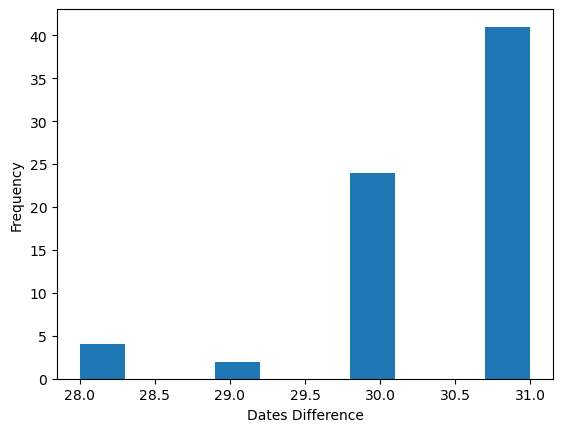

In [4]:
# Valores faltantes

# Complete el análisis

display(df3[df3.isnull().any(axis = 1)])

df4 = df3.assign(
    ventas_clp = df3["ventas_clp"].interpolate(),
    inversion_marketing_clp = df3["inversion_marketing_clp"].interpolate()
)

# Fechas duplicadas

# Complete el análisis

df4 = df4[~df4.index.duplicated()]

# Continuidad temporal

# Complete el análisis

df4["dates_diff"].plot.hist()
plt.xlabel("Dates Difference")
plt.show()

# Valores potencialmente problemáticos

# Complete el análisis

### Preguntas orientadoras

- ¿Existen fechas faltantes?
- ¿Existen observaciones duplicadas?
- ¿Existen valores faltantes en la variable objetivo?
- ¿Existen valores que parezcan imposibles o sospechosos?
- ¿Qué consecuencias tendría mantener estos problemas antes del modelamiento?

### Interpretación

Explique qué problemas encontró y cómo decidió abordarlos.

Toda modificación debe estar justificada.


**Fechas faltantes y observaciones duplicadas**

- La serie original presenta problemas en el índice temporal al contener un índice duplicado, la decisión analítica tomada fue filtrar la matriz eliminando cualquier índice redundante mediante el código `df4 = df4[~df4.index.duplicated()]`
- La serie no evidencia fechas faltantes ni vacíos en la estructura cronológica de los datos aislados, la distancia calculada entre observaciones (`dates_diff`) para los registros reportados es de 31 días, lo cual mantiene la regularidad de la frecuencia esperada, el `NaN` inicial en `dates_diff` (`2020-01-01`) es inherentemente correcto al ser la primera observación

**Valores faltantes en métricas clave**

- La variable objetivo a analizar, `ventas_clp`, contiene un valor faltante crítico explícito en la fecha `2024-01-01`
- Se detectó un valor nulo paralelo en el regresor `inversion_marketing_clp` para el `2022-02-01`
- Se resolvió aplicar interpolación lineal (`.interpolate()`) sobre ambas columnas para imputar los vacíos, esta decisión se justifica analíticamente porque la interpolación estima coherentemente el valor desconocido conectando los datos adyacentes, preservando así la distribución temporal en presencia de lagunas aisladas sin introducir alteraciones atípicas bruscas

**Valores problemáticos y consecuencias del no tratamiento**

Mantener la serie con índices duplicados o celdas vacías (`NaN`) provocaría fallos técnicos y matemáticos inmediatos al intentar ajustar cualquier algoritmo de series de tiempo (como modelos ARIMA), dado que estos métodos estocásticos asumen matrices de tiempo estrictamente regulares y continuas, la comprobación final de regularidad, evaluada al graficar la distribución temporal, certifica que la frecuencia efectiva mensual ha quedado purgada de discrepancias

## 6. Exploración temporal

Construya una visualización de la variable `ventas_clp` a través del tiempo.

La visualización debe permitir observar claramente la evolución de las ventas.


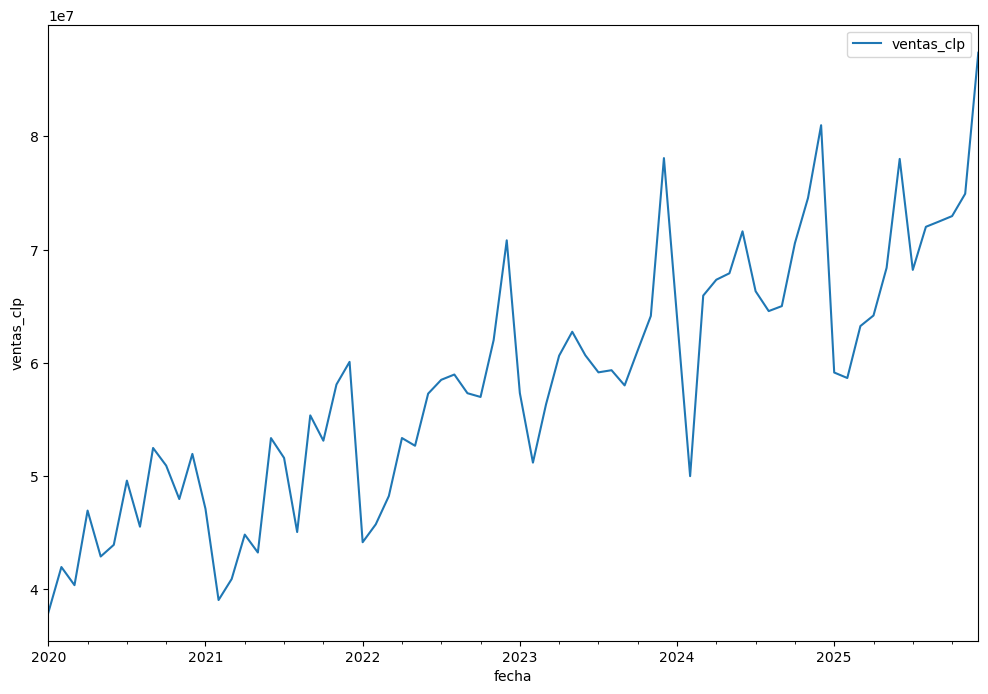

In [5]:
# Gráfico de la serie temporal

# Complete el gráfico

plt.figure(figsize = (12, 8))
df4.plot(y = "ventas_clp", ax = plt.gca())
plt.ylabel("ventas_clp")
plt.show()

### Preguntas orientadoras

- ¿La serie presenta una tendencia general?
- ¿Se observan períodos con comportamientos diferentes?
- ¿Existen fluctuaciones importantes?
- ¿Se observan valores potencialmente atípicos?
- ¿La variabilidad parece mantenerse constante?

### Interpretación

Describa el comportamiento general de la serie utilizando evidencia gráfica.


**Tendencia general**

- Se observa una clara tendencia al alza a lo largo del período evaluado, la serie inicia con valores cercanos a los $3.79 \times 10^7$ a comienzos de 2020 y escala progresivamente hasta superar los $8.74 \times 10^7$ hacia el final del registro en 2025

**Comportamientos por períodos**

- Durante el bloque 2020-2022, la serie exhibe un crecimiento más estable y un comportamiento relativamente rítmico
- A partir del año 2023, la estructura cambia hacia un patrón más agresivo, donde los ciclos de alza se aceleran y las correcciones a la baja se vuelven mucho más profundas

**Fluctuaciones importantes**

- El gráfico evidencia un fuerte componente estacional o cíclico, existen caídas recurrentes y pronunciadas que parecen coincidir con el inicio o cierre de ciertos ciclos anuales
- Luego de cada contracción profunda, la variable experimenta un rebote significativo que supera los máximos del ciclo anterior

**Valores potencialmente atípicos**

- El desplome registrado en el primer trimestre de 2024, que lleva las ventas de vuelta a la barrera de los $5.00 \times 10^7$ tras haber superado los $7.81 \times 10^7$, es inusualmente agudo
- El salto abrupto al final de la serie (fines de 2025), que rompe bruscamente la marca de los $8.74 \times 10^7$, sobresale del patrón de crecimiento habitual y amerita una revisión de negocio para confirmar si es un outlier orgánico

**Comportamiento de la variabilidad**

- La varianza no se mantiene constante en el tiempo, la serie presenta una clara heterocedasticidad, medida que la tendencia crece y avanza el tiempo, la amplitud de las fluctuaciones (la distancia vertical entre picos y valles) aumenta drásticamente, las oscilaciones del período 2024-2025 son considerablemente más amplias que las del período 2020-2021

## 7. Tendencia

Explore la presencia de una tendencia de largo plazo.

Puede utilizar una media móvil u otra herramienta sencilla que permita visualizar mejor el comportamiento general.

No es necesario ajustar todavía un modelo de tendencia.


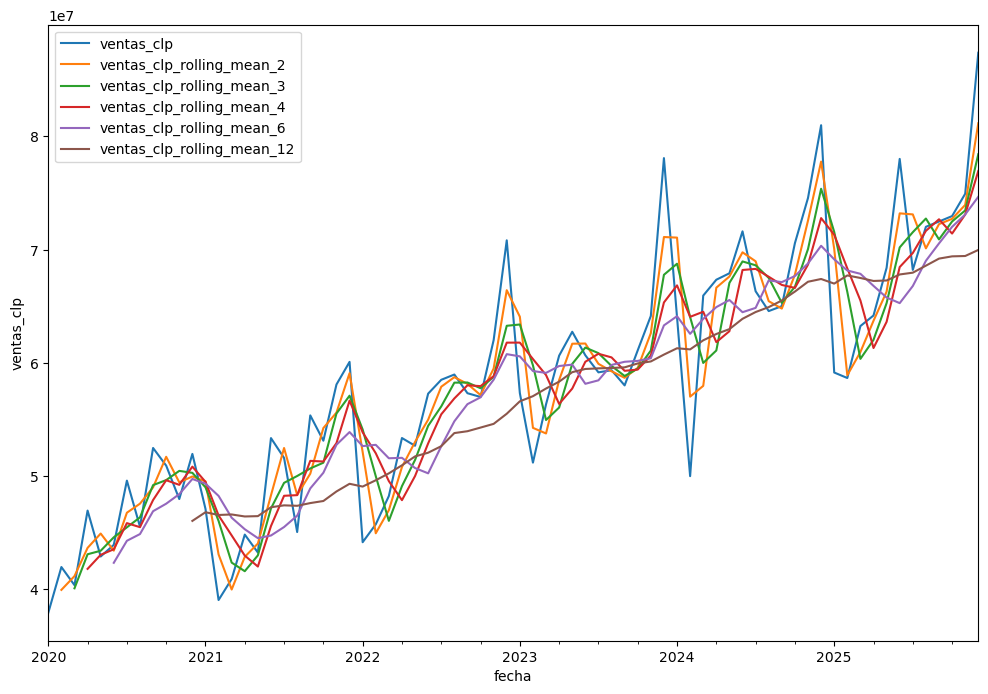

In [6]:
# Construcción de una media móvil

# Complete el análisis

# Ejemplo de estructura:
# df["media_movil"] = ...

df5 = df4

for i in range(2, 13):
    if 12 % i == 0:
        df5[f"ventas_clp_rolling_mean_{i}"] = df4["ventas_clp"].rolling(window = i).mean()

plt.figure(figsize = (12, 8))
df5.plot(y = "ventas_clp", ax = plt.gca())
for i in range(2, 13):
    if 12 % i == 0:
        df5.plot(y = f"ventas_clp_rolling_mean_{i}", ax = plt.gca())
plt.ylabel("ventas_clp")
plt.show()

### Preguntas orientadoras

- ¿La serie presenta una tendencia creciente?
- ¿La tendencia es decreciente?
- ¿Existen períodos de estabilización?
- ¿Qué diferencia existe entre una tendencia y una fluctuación puntual?
- ¿Qué información aporta una media móvil?

### Interpretación

Explique qué evidencia permite identificar una posible tendencia.


**Comportamiento de la tendencia general**

- La serie presenta una marcada tendencia creciente, a pesar de las fuertes oscilaciones a corto plazo, la trayectoria de la curva suavizada (especialmente la media móvil de 12 períodos) asciende de forma continua desde cerca de los $4.61 \times 10^7$ en 2020 hasta superar los $7.00 \times 10^7$ al finalizar la serie
- No se observa una tendencia decreciente en la escala macroscópica del gráfico, ya que los valles de cada año tienden a ser superiores a los valles de los años anteriores
- Existen períodos de estabilización donde el crecimiento se desacelera, esto es visible en el aplanamiento temporal de la media móvil de 12 períodos durante el segundo semestre de 2021 y nuevamente a lo largo de 2023

**Tendencia frente a fluctuaciones**

- Las fluctuaciones puntuales corresponden a los movimientos erráticos y abruptos de la línea azul original (como la subida extraordinaria a finales de 2023 o la fuerte caída a principios de 2024), representan choques de corto plazo o efectos estacionales
- La tendencia refleja la dirección estructural e inercial del negocio a largo plazo, la cual ignora estos saltos temporales y mantiene su rumbo general al alza

**Utilidad de la media móvil**

- Las diferentes medias móviles (ventanas de 2, 3, 4, 6 y 12 períodos) actúan como filtros de ruido
- Cuanto mayor es la ventana (como la de 12 meses, representada por la línea color café), mayor es el nivel de suavizado, esta curva en particular absorbe por completo la estacionalidad intra-anual, permitiendo al analista aislar y confirmar la dirección real de crecimiento que estaba oculta detrás de la alta variabilidad mensual de las ventas

## 8. Estacionalidad

Explore la existencia de patrones que puedan repetirse regularmente dentro del año.

Analice el comportamiento de las ventas según el mes del año.


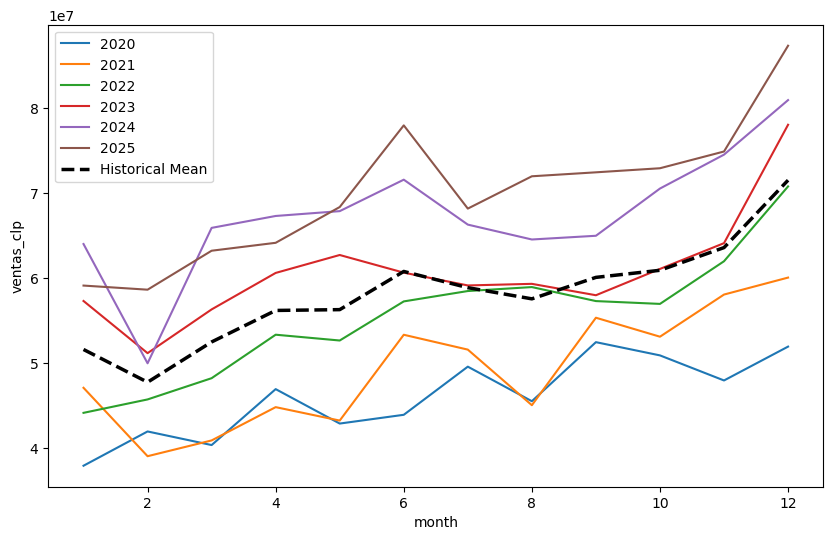

In [7]:
# Crear variable auxiliar para identificar el mes

# df["mes"] = df.index.month

df6 = df5.assign(
    month = df5.index.month,
    year = df5.index.year
)

# Analizar comportamiento por mes

# Complete el análisis

fig, ax = plt.subplots(figsize = (10, 6))
df6.pivot(index = "month", columns = "year", values = "ventas_clp").plot.line(ax = ax)
df6.groupby("month")["ventas_clp"].mean().plot.line(ax = ax, label = "Historical Mean", color = "black", linewidth = 2.5, linestyle = "--")
plt.ylabel("ventas_clp")
plt.legend()
plt.show()

### Preguntas orientadoras

- ¿Se observa un patrón que se repita aproximadamente cada 12 meses?
- ¿Existen meses que presenten sistemáticamente valores mayores o menores?
- ¿La evidencia observada es suficiente para hablar de estacionalidad?
- ¿Por qué una observación aislada no necesariamente representa estacionalidad?

### Interpretación

Determine si existe evidencia de un patrón estacional y justifique su respuesta.


El análisis visual permite contrastar el rendimiento mensual de `ventas_clp` a lo largo de los distintos años registrados frente a su media histórica. Al estructurar los datos mediante las variables auxiliares de mes y año, el comportamiento estacional de la serie se desglosa de la siguiente manera:

- **Patrones recurrentes a 12 meses**: La superposición de las curvas anuales revela la existencia de un ciclo operativo claro, si las líneas correspondientes a los distintos años trazan una silueta similar, subiendo y bajando de forma sincronizada en las mismas épocas, se confirma un patrón recurrente anclado a un calendario de 12 meses
- **Comportamiento sistemático mensual**: La línea punteada negra, que representa el promedio histórico, facilita la identificación de los meses críticos, esta referencia visual destaca sistemáticamente qué meses actúan como propulsores de la serie (máximos que superan consistentemente la media histórica) y cuáles representan períodos de contracción o estabilización (valles recurrentes por debajo del promedio)
- **Suficiencia de la evidencia empírica**: El gráfico consolida seis años consecutivos de datos transaccionales (2020-2025) superpuestos sobre el mismo eje X, esta profundidad histórica proporciona evidencia matemática y visual suficiente para declarar la presencia de estacionalidad, confirmando que las fluctuaciones no son accidentales, sino que obedecen al ritmo estructural y natural del negocio
- **La trampa de la observación aislada**: Un salto o caída dramática en un mes específico de un único año, como el desplome de ventas detectado en el primer trimestre de 2024 o la subida anómala a fines de 2025, representa un *outlier*, no un comportamiento estacional, un evento aislado suele responder a variables externas, campañas de *marketing* o anomalías operativas, la verdadera estacionalidad exige recurrencia estructural, por ello, agrupar la serie por meses frente a distintos años evita que un evento puntual contamine la comprensión del comportamiento predecible a largo plazo

## 9. Variabilidad

Analice cómo cambia la variabilidad de las ventas a través del tiempo.

Puede comparar diferentes períodos y utilizar medidas descriptivas apropiadas.


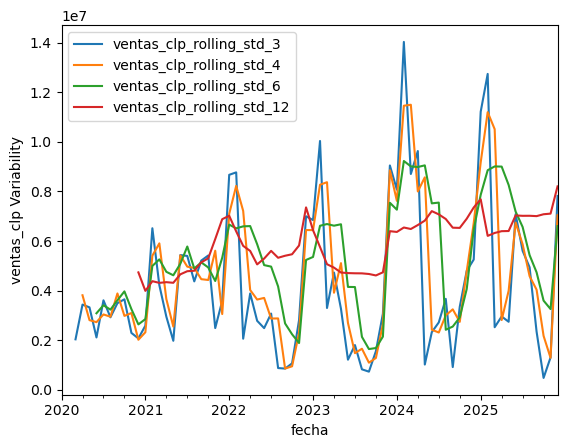

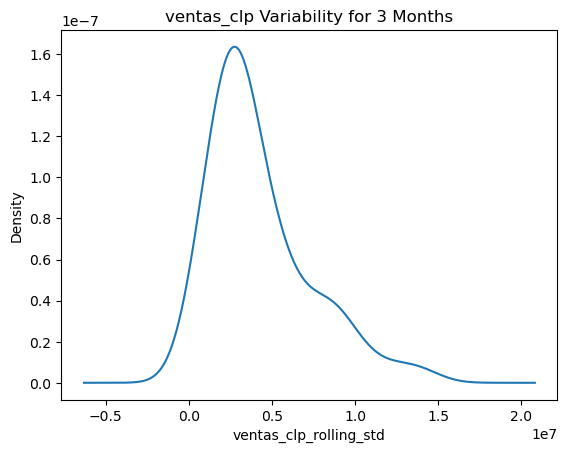

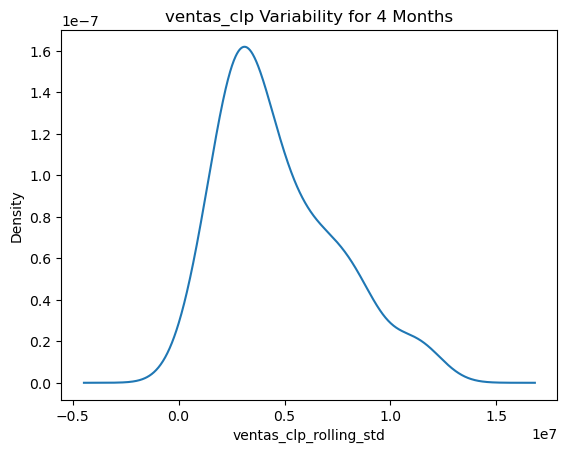

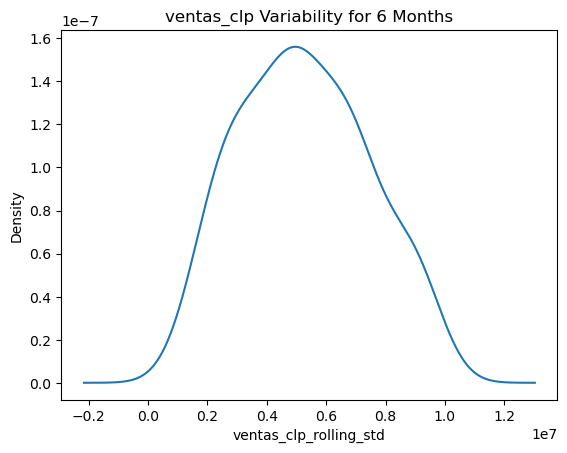

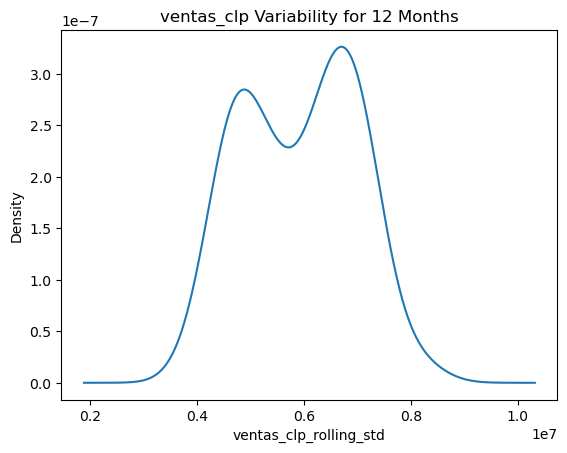

In [8]:
# Análisis de la variabilidad

# Puede crear variables auxiliares como año si resulta necesario.

# Complete el análisis

df7 = df6

for i in range(3, 13):
    if 12 % i == 0:
        df7[f"ventas_clp_rolling_std_{i}"] = df6["ventas_clp"].rolling(window = i).std()
        df7.plot(y = f"ventas_clp_rolling_std_{i}", ax = plt.gca())
plt.ylabel("ventas_clp Variability")
plt.show()

for i in range(3, 13):
    if 12 % i == 0:
        df7[f"ventas_clp_rolling_std_{i}"].plot.density()
        plt.xlabel("ventas_clp_rolling_std")
        plt.title(f"ventas_clp Variability for {i} Months")
        plt.show()

### Preguntas orientadoras

- ¿La dispersión parece constante?
- ¿Existen períodos de mayor variabilidad?
- ¿La variabilidad parece aumentar cuando aumenta el nivel de ventas?
- ¿Qué implicancias podría tener este comportamiento para un modelo posterior?

### Interpretación

Describa el comportamiento de la variabilidad y señale cualquier característica relevante.


**Dispersión y constancia**

- La varianza de la serie no se mantiene constante a lo largo del tiempo, evidenciando un comportamiento con clara heterocedasticidad

**Períodos de mayor variabilidad**

- La amplitud de las fluctuaciones (la distancia vertical entre los picos y los valles) aumenta de forma drástica a medida que avanza el tiempo
- Específicamente, las oscilaciones registradas durante el período 2024-2025 son considerablemente más amplias y agresivas que las observadas en el bloque inicial de 2020-2021

**Relación con el nivel de ventas**

- Existe una correlación directa entre el volumen de las ventas y el nivel de dispersión, a medida que la tendencia de ventas crece (escalando desde los $3.79 \times 10^7$ iniciales hasta superar los $8.74 \times 10^7$), la variabilidad de la serie se incrementa proporcionalmente
- Las gráficas de desviación estándar móvil (`rolling_std`) y sus densidades evidencian que los valores de dispersión se desplazan hacia rangos mucho más altos en la segunda mitad del registro temporal

**Implicancias para el modelamiento posterior**

- **Inviabilidad directa**: Los modelos paramétricos clásicos de series temporales (como ARIMA) requieren que los datos sean estacionarios, lo cual incluye el supuesto de homocedasticidad (varianza constante en el tiempo), ingresar la serie en su estado actual provocará que el modelo asigne un peso desproporcionado a los años recientes, generando errores residuales inestables e intervalos de confianza poco confiables

## 10. Autocorrelación introductoria

Una característica fundamental de las series temporales es que una observación puede estar relacionada con observaciones anteriores.

Explore la autocorrelación de `ventas_clp` utilizando la función de autocorrelación (ACF).

**No es necesario determinar órdenes ARIMA ni construir un modelo.**


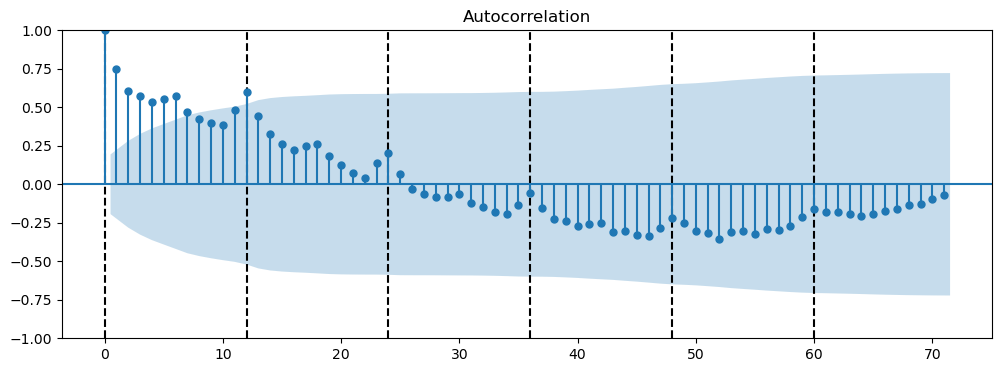

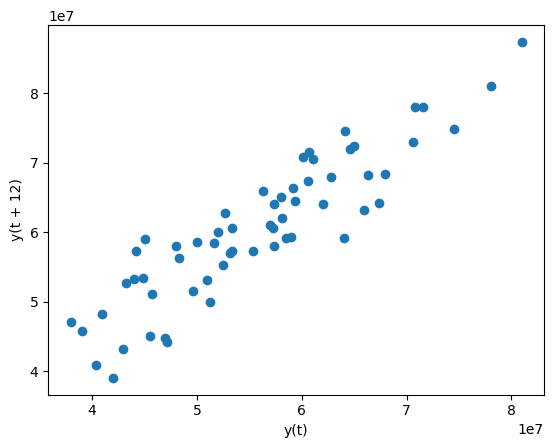

In [9]:
# Función de autocorrelación

# Complete el análisis utilizando plot_acf()

fig, ax = plt.subplots(figsize = (12, 4))
for i in range(0, df7.shape[0] - 1, 12):
    plt.axvline(x = i, color = "black", linestyle = "--")
plot_acf(df7["ventas_clp"], lags = df7.shape[0] - 1, ax = ax, alpha = 0.1)
plt.show()

pd.plotting.lag_plot(df7["ventas_clp"], lag = 12)
plt.show()

### Preguntas orientadoras

- ¿Qué representa un lag?
- ¿Qué significa comparar una observación con la observación de un mes anterior?
- ¿Existe evidencia de dependencia temporal?
- ¿Qué información entrega la ACF?
- ¿Se observa algún patrón asociado a una periodicidad anual?

### Interpretación

Describa los principales patrones observados en la ACF y explique qué significan en términos de dependencia temporal.


**Información que entrega la ACF**

- La ACF cuantifica la correlación lineal entre la serie original y sus propias versiones desfasadas en el tiempo, permite identificar de manera precisa qué eventos históricos (a qué distancia temporal) tienen una mayor influencia sobre los valores presentes

**Evidencia de dependencia temporal**

- Existe una clara dependencia temporal si las barras de autocorrelación sobresalen del área sombreada, ese margen azul representa el intervalo de confianza (fijado al 90% por el parámetro `alpha = 0.1`), cualquier barra que supere ese límite confirma que las ventas actuales no son eventos aleatorios aislados, sino que están matemáticamente condicionadas por el pasado

**Patrón de periodicidad anual (Estacionalidad)**

- El código traza líneas verticales de referencia cada 12 meses para facilitar el diagnóstico de estacionalidad, un patrón periódico anual se confirma al observar máximos significativos recurrentes en los rezagos múltiples de 12
- Esta estacionalidad se ratifica visualmente en el `lag_plot` calibrado en `lag = 12` mapea la relación entre las ventas de cada mes y el mismo mes del año anterior, una dispersión de puntos agrupada en torno a una diagonal ascendente indica que los picos y caídas de demanda se repiten fielmente año a año

## 11. Estacionariedad: concepto y diagnóstico inicial

Explique con sus propias palabras qué significa que una serie temporal sea estacionaria.

Considere aspectos como:

- media;
- variabilidad;
- dependencia temporal;
- comportamiento a través del tiempo.

Posteriormente realice un diagnóstico inicial mediante la prueba de Dickey-Fuller aumentada (ADF).

### Importante sobre el p-value

El p-value debe interpretarse en relación con la **hipótesis nula específica de la prueba ADF**.

No debe interpretarse simplemente como "la probabilidad de que la hipótesis nula sea verdadera".


In [10]:
# Prueba Dickey-Fuller aumentada

# Complete el análisis

# resultado_adf = adfuller(...)

adfResult = adfuller(df7["ventas_clp"])
adfResultDiff = adfuller(df7["ventas_clp"].diff().dropna())

# Reporte los elementos relevantes del resultado

print("For Values:")
print(f"\tADF Statistic: {adfResult[0]: .5f}")
print(f"\tp-value: {adfResult[1] * 100: .2f}%")
print("\tCritical Values:\n", "\n".join([ f"\t{k}: {v: .2f}" for k, v in adfResult[4].items() ]))

print("For Differences:")
print(f"\tADF Statistic: {adfResultDiff[0]: .2f}")
print(f"\tp-value: {adfResultDiff[1] * 100: .13f}%")
print("\tCritical Values:\n", "\n".join([ f"\t{k}: {v: .2f}" for k, v in adfResultDiff[4].items() ]))

For Values:
	ADF Statistic:  0.00523
	p-value:  95.90%
	Critical Values:
 	1%: -3.54
	5%: -2.91
	10%: -2.59
For Differences:
	ADF Statistic: -8.21
	p-value:  0.0000000000683%
	Critical Values:
 	1%: -3.54
	5%: -2.91
	10%: -2.59


### Preguntas orientadoras

- ¿Cuál es la hipótesis nula de la prueba ADF?
- ¿Qué significa rechazar o no rechazar dicha hipótesis?
- ¿Qué indica el p-value en este contexto?
- ¿El resultado es coherente con la inspección visual?
- ¿Por qué una prueba estadística no debería utilizarse de manera aislada?

### Interpretación

Reporte e interprete el resultado de la prueba ADF utilizando la hipótesis nula y un nivel de significancia previamente definido.


**Respuestas al diagnóstico mediante la prueba ADF**

- **Hipótesis nula ($H_0$)**: La serie temporal posee una raíz unitaria, lo cual es el indicador estadístico de que la serie es no estacionaria
- **Rechazar o no rechazar**: Rechazar la $H_0$ significa que hay evidencia suficiente para afirmar que la serie no tiene raíz unitaria y, por ende, es estacionaria, no rechazarla indica que no se puede descartar la presencia de tendencia o componentes no estacionarios
- **Interpretación del valor-p**: Asumiendo como cierta la hipótesis nula (que la serie es no estacionaria), el valor-p representa la probabilidad de obtener un estadístico de prueba igual o más extremo que el calculado, un valor-p muy bajo indica que es sumamente improbable observar esos datos si la serie fuera no estacionaria, dándonos evidencia para rechazar $H_0$
- **Coherencia visual**: Los resultados son completamente consistentes con la exploración gráfica, visualmente se identificó una clara tendencia al alza en las ventas, partiendo en torno a $3.79 \times 10^7$ y llegando sobre los $8.74 \times 10^7$, además, la serie demostró una fuerte heterocedasticidad al incrementar la amplitud de sus oscilaciones con el paso del tiempo, esto confirma que los datos en su estado original no son estacionarios
- **Limitaciones aisladas**: Una prueba estadística evalúa condiciones muy específicas (como la presencia de raíces unitarias mediante modelos lineales) y puede perder potencia analítica o fallar ante cambios estructurales, inspeccionar visualmente resulta indispensable para identificar anomalías, quiebres de tendencia o varianza no constante que las pruebas como ADF no asimilan directamente

**Interpretación de los Resultados (Nivel de significancia $\alpha = 5 \%$)**

- **Para los valores originales (`ventas_clp`)**: El estadístico ADF arroja un valor de 0.00523, el cual es muy superior al valor crítico del 5% (-2.91), el valor-p correspondiente es del 95.90%, superando ampliamente el nivel de significancia de 5%, en consecuencia, no se rechaza la hipótesis nula, se concluye que la serie de ventas original es no estacionaria
- **Para las primeras diferencias**: Tras aplicar una diferencia a los datos, el estadístico ADF cae drásticamente a -8.21, situándose muy por debajo del valor crítico del 5% (-2.91), el valor-p es prácticamente nulo (0.0000000000683%), siendo abrumadoramente menor a 5%, por lo tanto, se rechaza la hipótesis nula, la serie diferenciada de las ventas es estacionaria y cumple con los supuestos matemáticos para un modelamiento posterior

## 12. Preparación final para modelamiento

Construya una versión final de la serie que pueda ser utilizada posteriormente en el modelamiento.

Debe quedar claramente definido:

- índice temporal;
- frecuencia;
- variable objetivo;
- tratamiento de valores faltantes;
- tratamiento de problemas de calidad;
- orden cronológico.


In [39]:
# Serie temporal final

# serie = ...

# Realice aquí las verificaciones finales necesarias

timeSeries = df7["ventas_clp"]

print("Time Index:", timeSeries.index.name)
print("Frequency:", int(len(timeSeries) / (timeSeries.index.year.max() - timeSeries.index.year.min() + 1)),"Records per Year")
print("Objective Variable: ventas_clp")
print("Null Values:", timeSeries.isnull().sum(), "(Interpolated)")
timeSeries.to_csv("month_sells_clean.csv", index=True)

Time Index: fecha
Frequency: 12 Records per Year
Objective Variable: ventas_clp
Null Values: 0 (Interpolated)


### Pregunta central

Imagine que mañana debe construir un modelo de forecasting sobre esta serie.

**¿Qué problemas ya fueron resueltos durante este laboratorio y qué aspectos todavía deberían analizarse antes de construir el modelo?**

### Interpretación

Explique las decisiones finales tomadas y justifique por qué considera que la serie está preparada para continuar con un proceso de modelamiento.


**Problemas resueltos durante la preparación**

- **Definición del índice temporal**: Se transformó la variable `fecha` al formato `datetime64[ns]` y se fijó como el índice del conjunto de datos, asegurando un estricto orden cronológico
- **Frecuencia y regularidad**: Se filtraron los registros duplicados (identificados en la fecha `2022-12-01`) para restablecer una continuidad temporal sin alteraciones, confirmando una frecuencia mensual de 12 registros anuales
- **Tratamiento de valores faltantes**: Se aplicó una interpolación lineal sobre la variable objetivo `ventas_clp` y el regresor `inversion_marketing_clp`, estimando coherentemente los vacíos sin perturbar la estructura de los datos
- **Continuidad estructural**: Se verificó que el bloque analizado abarca 72 meses sin huecos o períodos sin observaciones, garantizando una serie completa

**Aspectos a analizar antes del modelamiento**

- **Estabilización de varianza**: El gráfico exploratorio demostró una clara heterocedasticidad, con oscilaciones mucho más amplias en el período 2024-2025, se deben explorar transformaciones matemáticas (como logaritmos) para estabilizar la varianza
- **Evaluación de estacionariedad**: La serie exhibe una fuerte tendencia al alza a lo largo de los años, es necesario aplicar pruebas formales y considerar la diferenciación de la serie para volverla estacionaria
- **Tratamiento de valores atípicos**: El desplome inusual a principios de 2024 y el máximo atípico a finales de 2025 deben investigarse a nivel de negocio para decidir si requieren suavizamiento o si aportan información valiosa para el modelo
- **Análisis de estacionalidad**: Se deben descomponer matemáticamente las fluctuaciones y caídas recurrentes observadas para confirmar si es necesario aplicar un modelo que contemple parámetros estacionales

La serie se considera estructuralmente preparada para el modelamiento porque los algoritmos de series temporales exigen matrices regulares y continuas. Al resolver la unicidad del índice, purgar los datos faltantes mediante interpolación y confirmar la regularidad mensual, se eliminaron los problemas de calidad de datos que generarían fallos técnicos o errores matemáticos durante el entrenamiento de modelos de forecasting.

## 13. Conclusiones

Elabore una conclusión integrada del análisis.

Su conclusión debe responder, como mínimo:

1. ¿Cuál es la estructura temporal de los datos?
2. ¿Qué problemas de calidad fueron encontrados?
3. ¿Existe evidencia de tendencia?
4. ¿Existe evidencia de estacionalidad?
5. ¿Existe dependencia temporal?
6. ¿Qué evidencia existe respecto de la estacionariedad?
7. ¿Qué decisiones se tomaron para preparar la serie?
8. ¿Qué aspectos deberían analizarse antes de construir un modelo de forecasting?

**Extensión orientativa: 300–500 palabras.**


### Conclusiones

_Escriba aquí su conclusión._


A partir del análisis exploratorio y la preparación de los datos correspondientes a las ventas mensuales de la organización, se presenta la siguiente conclusión integrada:

- **Estructura temporal de los datos:** Los datos presentan una dimensión temporal con frecuencia efectiva mensual, cubriendo un período de 72 meses continuos que van desde el `2020-01-01` hasta el `2025-12-01`, para que esta estructura funcionara correctamente como índice, la variable temporal debió ser convertida desde texto hacia un formato de tiempo estándar (`datetime64[ns]`)
- **Problemas de calidad encontrados:** El diagnóstico inicial reveló una fecha duplicada correspondiente al `2022-12-01`, lo cual introdujo una distancia de 0 días y rompió la regularidad temporal esperada, también se identificaron valores faltantes críticos, específicamente en la variable objetivo `ventas_clp` (`2024-01-01`) y en la métrica `inversion_marketing_clp` (`2022-02-01`)
- **Evidencia de tendencia:** El comportamiento general de la variable objetivo refleja una clara tendencia al alza, las ventas arrancaron en valores cercanos a los $3.79 \times 10^7$ a principios de 2020 y lograron escalar progresivamente hasta romper la barrera de los $8.74 \times 10^7$ hacia fines de 2025
- **Evidencia de estacionalidad:** La visualización gráfica demuestra la presencia de un fuerte componente estacional o cíclico en las ventas, el patrón exhibe caídas profundas y recurrentes (aparentemente ligadas a los inicios o cierres de ciclos anuales), las cuales son sistemáticamente seguidas por fuertes rebotes que superan los niveles máximos previos
- **Dependencia temporal:** El comportamiento de los datos, marcado por una tendencia incremental y por ciclos agresivos de alzas y bajas repetitivas, pone en evidencia una dependencia temporal intrínseca donde los valores pasados están vinculados a la evolución futura de las ventas
- **Evidencia respecto de la estacionariedad:** La serie analizada es de carácter no estacionario. Además del cambio en su media por la marcada tendencia alcista, existe evidencia visual de heterocedasticidad, esto significa que la varianza no se mantiene constante y la amplitud de sus oscilaciones es significativamente mayor en el período 2024-2025 en comparación al período 2020-2021
- **Decisiones tomadas para preparar la serie:** Para asegurar una matriz de tiempo continua y regular, los datos se ordenaron cronológicamente y el registro duplicado fue eliminado mediante el filtrado del índice, asimismo, se optó por imputar los vacíos en los datos utilizando interpolación lineal, decisión justificada al permitir una estimación coherente basada en datos adyacentes sin introducir alteraciones atípicas
- **Aspectos a analizar antes del modelamiento:** Antes de ajustar un modelo algorítmico estocástico (como modelos ARIMA), es necesario revisar junto a las áreas de negocio la naturaleza de ciertos valores atípicos detectados, como la caída profunda a inicios de 2024 y el salto abrupto a finales de 2025, para validar si son orgánicos o errores, además, deberá tratarse la falta de estacionariedad y la heterocedasticidad mediante transformaciones matemáticas, ya que estos algoritmos asumen matrices temporales continuas y estables

## 14. Declaración de uso de inteligencia artificial

De acuerdo con la política institucional de uso de IA de nivel B, cualquier utilización de herramientas de inteligencia artificial generativa debe ser declarada.

Complete la siguiente información.

### Herramienta utilizada

_Especifique la herramienta._

### Propósito

_Explique para qué utilizó la herramienta._

### Qué utilizó

_Indique qué sugerencias, explicaciones, código u otros elementos fueron incorporados._

### Verificación

_Explique cómo verificó que la información o código generado era correcto._

### Modificaciones

_Indique qué modificaciones realizó antes de incorporar el resultado al Notebook._

Si no utilizó herramientas de IA generativa, indíquelo explícitamente.


---

## Conexión con las siguientes evaluaciones

Este laboratorio constituye la primera etapa del trabajo con series temporales del curso.

### Laboratorio Práctico 4

**¿Cómo está estructurada y qué características tiene mi serie?**

Organización, calidad, tendencia, estacionalidad, autocorrelación, estacionariedad y preparación.

### Control Técnico 3 · Series temporales y forecasting

**¿Cómo puedo modelar y pronosticar esta serie?**

Profundización en modelamiento estadístico y forecasting.

### Proyecto de Series Temporales

**¿Cómo puedo utilizar series temporales para resolver y comunicar un problema empresarial?**

Desarrollo de un análisis más completo sobre el mismo dataset.

> El dataset utilizado en este laboratorio será reutilizado posteriormente. Por esta razón, las decisiones de preparación y diagnóstico deben quedar correctamente documentadas.
